# 06: Visium HD single-cell integration & QC

Quality and cell-type annotation of the **Visium HD whole-cell** data. Each
Space-Ranger–segmented cell has its transcripts aggregated, and cell-type
composition is estimated with **cell2location** (a negative-binomial reference from
the matched dissociated scRNA-seq, mapped onto the spatial cells). The 22 reference
classes are consolidated to **13 classes**; each cell takes its highest-abundance
class, keeping only calls that clear a per-type confidence margin.

Panels: mapped cell type in space · cell2location abundance maps · marker-gene
specificity heatmap · spatial density of the barcode RNA · sequencing depth vs
matched scRNA-seq · spatial autocorrelation of the barcode signal · barcode
coverage per sgRNA.

**Inputs** (place under `data/`, relative paths):
* `data/visium_{sample}_cells_final.h5ad` — cell2location-annotated cells:
  `obs['cell_type']`, `obs['total_counts']`, `obs['n_genes_by_counts']`,
  `obsm['spatial_fullres']`, `obsm['q05_cell_abundance_w_sf']`, `obs['cell_id']`.
* `data/cell_barcode_{sample}.npz` — cell × barcode matrix.
* `data/RNAseq/{sample}.h5ad` — matched dissociated scRNA-seq (depth panel only).


In [1]:
import numpy as np, pandas as pd, scipy.sparse as sp, anndata as ad
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.neighbors import NearestNeighbors

DATA = Path('data') if Path('data').exists() else Path('../data')   # repo-root or notebooks/
SAMPLES = ['1RR', '2N']
CELLTYPE_ORDER = ['cancer', 'CAF', 'endothelial', 'neutrophil', 'monocyte', 'MDSC',
                  'macrophage', 'DC', 'NK', 'Treg', 'CD8', 'CD4', 'chemokine']
CELLTYPE_PALETTE = {
    'cancer': '#C26A3E', 'CAF': '#A8763E', 'endothelial': '#7C2E5A', 'neutrophil': '#3E6E94',
    'monocyte': '#5A8FBF', 'MDSC': '#6F9FBF', 'macrophage': '#2E5575', 'DC': '#4B8B6C',
    'NK': '#6FB089', 'Treg': '#B47CB0', 'CD8': '#84509A', 'CD4': '#A07AC2',
    'chemokine': '#888888', 'low_quality': '#DDDDDD'}
SAMPLE_COLOR = {'1RR': '#3E6E94', '2N': '#7C2E5A'}
SAMPLE_COLOR_SC = {'1RR': '#7AB0CE', '2N': '#B17AAE'}
VIS_C, SC_C, SEQ = '#4C72B0', '#DD8452', 'magma'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
                     'legend.fontsize': 10, 'figure.titlesize': 15, 'axes.titleweight': 'normal',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})
print('setup done')


setup done


## How `cell_barcode_{sample}.npz` is produced

The barcode table is built once by aggregating the raw 2 µm-bin barcode counts up to
segmented cells (bin → cell mapping from `barcode_mappings.parquet`). The function
below is the exact producer; it is skipped when the `.npz` is already present, so
**Run-All uses the provided file**. (The annotated `visium_{sample}_cells_final.h5ad`
is the cell2location output and is provided as an input.)


In [2]:
def build_cell_barcode_npz(sample):
    out = DATA / f'cell_barcode_{sample}.npz'
    if out.exists():
        return out                                   # provided -> nothing to do
    binh5 = ad.read_h5ad(DATA / f'visiumHD/{sample}/{sample}_square_002um.h5ad')
    labels_1read = binh5.obsm['labels_1read']        # (n_bins, n_barcodes), CSR
    barcodes = np.asarray(binh5.uns['labels_1read'])
    mp = pd.read_parquet(DATA / f'visiumHD/{sample}/barcode_mappings.parquet')
    mp = mp[mp.in_cell & mp.cell_id.notna()]
    cells, cell_idx = np.unique(mp.cell_id.values, return_inverse=True)
    cell_x_bin = sp.csr_matrix((np.ones(len(mp)), (cell_idx, mp.square_002um.values)),
                               shape=(len(cells), labels_1read.shape[0]))
    M = (cell_x_bin @ labels_1read).tocsr().astype('int32')
    np.savez_compressed(out, cells=cells, barcodes=barcodes,
                        data=M.data, indices=M.indices, indptr=M.indptr, shape=M.shape)
    return out

for s in SAMPLES:
    build_cell_barcode_npz(s)      # no-op when the npz is provided
print('barcode tables ready')


barcode tables ready


## Load each sample

Per-cell arrays come straight from the annotated h5ad; the barcode matrix is aligned
to the same cells by `cell_id`.


In [3]:
def load_qc(sample):
    a = ad.read_h5ad(DATA / f'visium_{sample}_cells_final.h5ad', backed='r')
    out = dict(cell_id=a.obs['cell_id'].astype(str).values,
               cell_type=a.obs['cell_type'].astype(str).values,
               total_counts=np.asarray(a.obs['total_counts'], float),
               n_genes=np.asarray(a.obs['n_genes_by_counts'], float),
               XY=np.asarray(a.obsm['spatial_fullres'], np.float32),
               q05=np.asarray(a.obsm['q05_cell_abundance_w_sf']),
               q05_cols=list(a.uns.get('cell_type_vocab', CELLTYPE_ORDER)))
    a.file.close()
    return out

def load_barcode(sample, QC):
    z = np.load(DATA / f'cell_barcode_{sample}.npz', allow_pickle=True)
    M = sp.csr_matrix((z['data'], z['indices'], z['indptr']), shape=tuple(z['shape']))
    bc_cells = z['cells'].astype(str)
    pos = {c: i for i, c in enumerate(QC['cell_id'])}
    rows = np.fromiter((pos.get(c, -1) for c in bc_cells), np.int64, len(bc_cells))
    ok = rows >= 0
    return QC['XY'][rows[ok]].astype(float), M[ok].tocsc(), z['barcodes'].astype(str)

QC = {s: load_qc(s) for s in SAMPLES}
for s in SAMPLES:
    q = QC[s]
    n_typed = pd.Series(q['cell_type']).value_counts().drop('low_quality', errors='ignore').shape[0]
    print(f"{s}: {len(q['cell_type']):,} cells  ·  median UMI {np.median(q['total_counts']):.0f}  ·  {n_typed} annotated types")


1RR: 212,319 cells  ·  median UMI 895  ·  13 annotated types
2N: 130,315 cells  ·  median UMI 681  ·  13 annotated types


## Mapped cell type in space

Every segmented cell at its centroid, coloured by its cell2location call;
`low_quality` (below-margin) cells are faint grey.


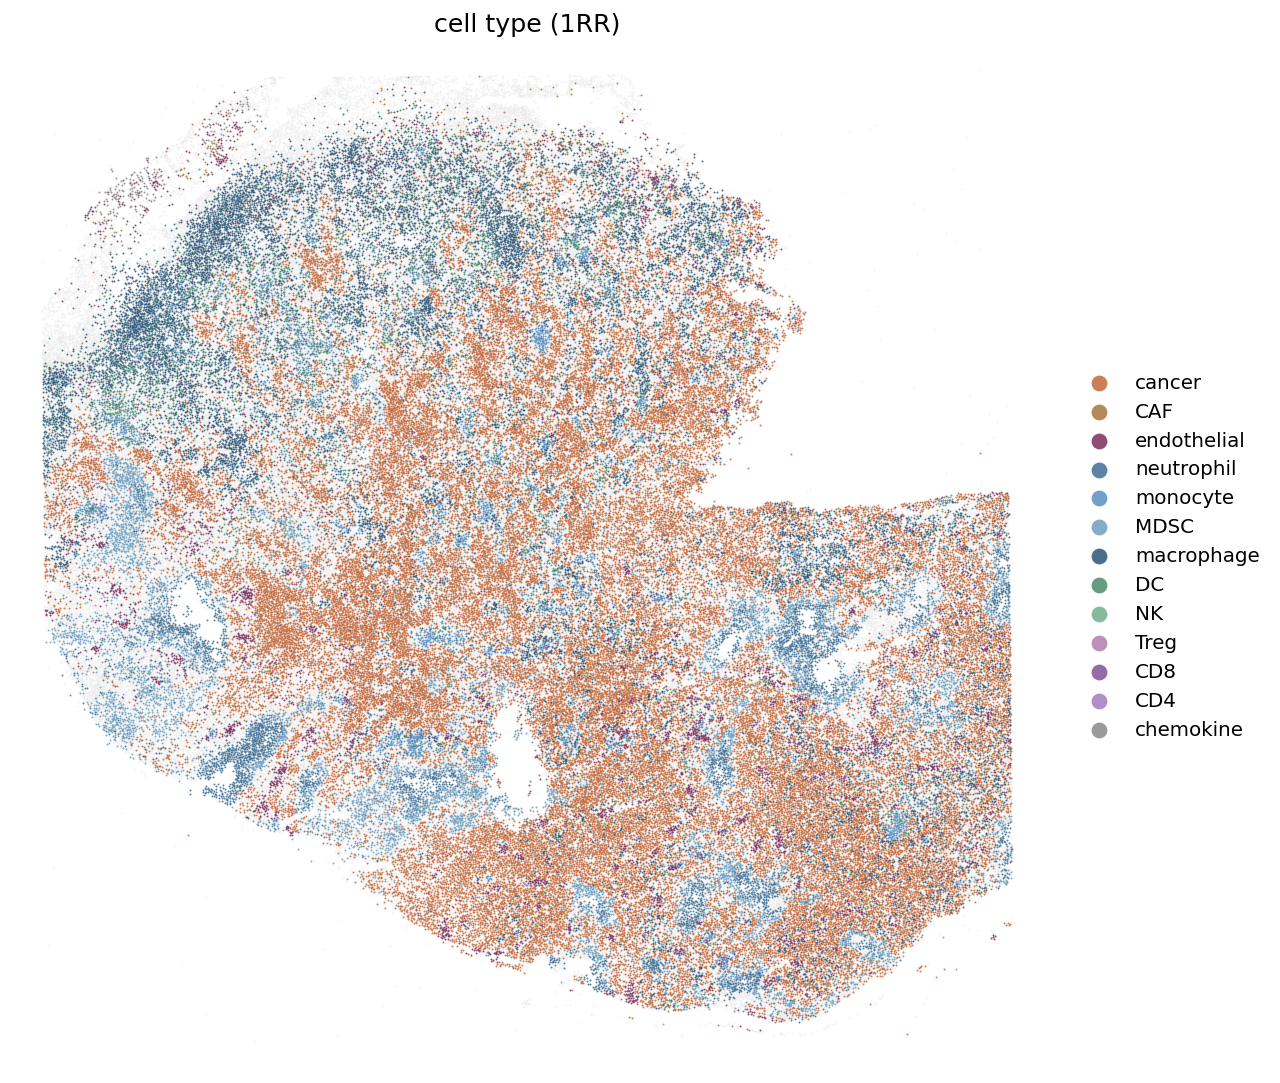

In [4]:
def celltype_spatial(ax, q, title):
    ct, XY = q['cell_type'], q['XY']
    for t in ['low_quality'] + CELLTYPE_ORDER:
        m = ct == t
        if m.any():
            ax.scatter(XY[m, 0], XY[m, 1], s=1.2, c=CELLTYPE_PALETTE.get(t, '#999'),
                       alpha=0.35 if t == 'low_quality' else 0.85, lw=0, rasterized=True,
                       label=None if t == 'low_quality' else t)
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    for sp_ in ax.spines.values():
        sp_.set_visible(False)
    ax.margins(0.03); ax.set_title(title)
    ax.legend(markerscale=8, fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5),
              frameon=False, ncol=1)

fig, ax = plt.subplots(figsize=(10.5, 8.5))
celltype_spatial(ax, QC['1RR'], 'cell type (1RR)')
fig.tight_layout()


## cell2location abundance maps

The q05 (5th-percentile posterior) abundance field for representative cell types on
the 1RR section — the continuous fields the discrete call is an argmax of.


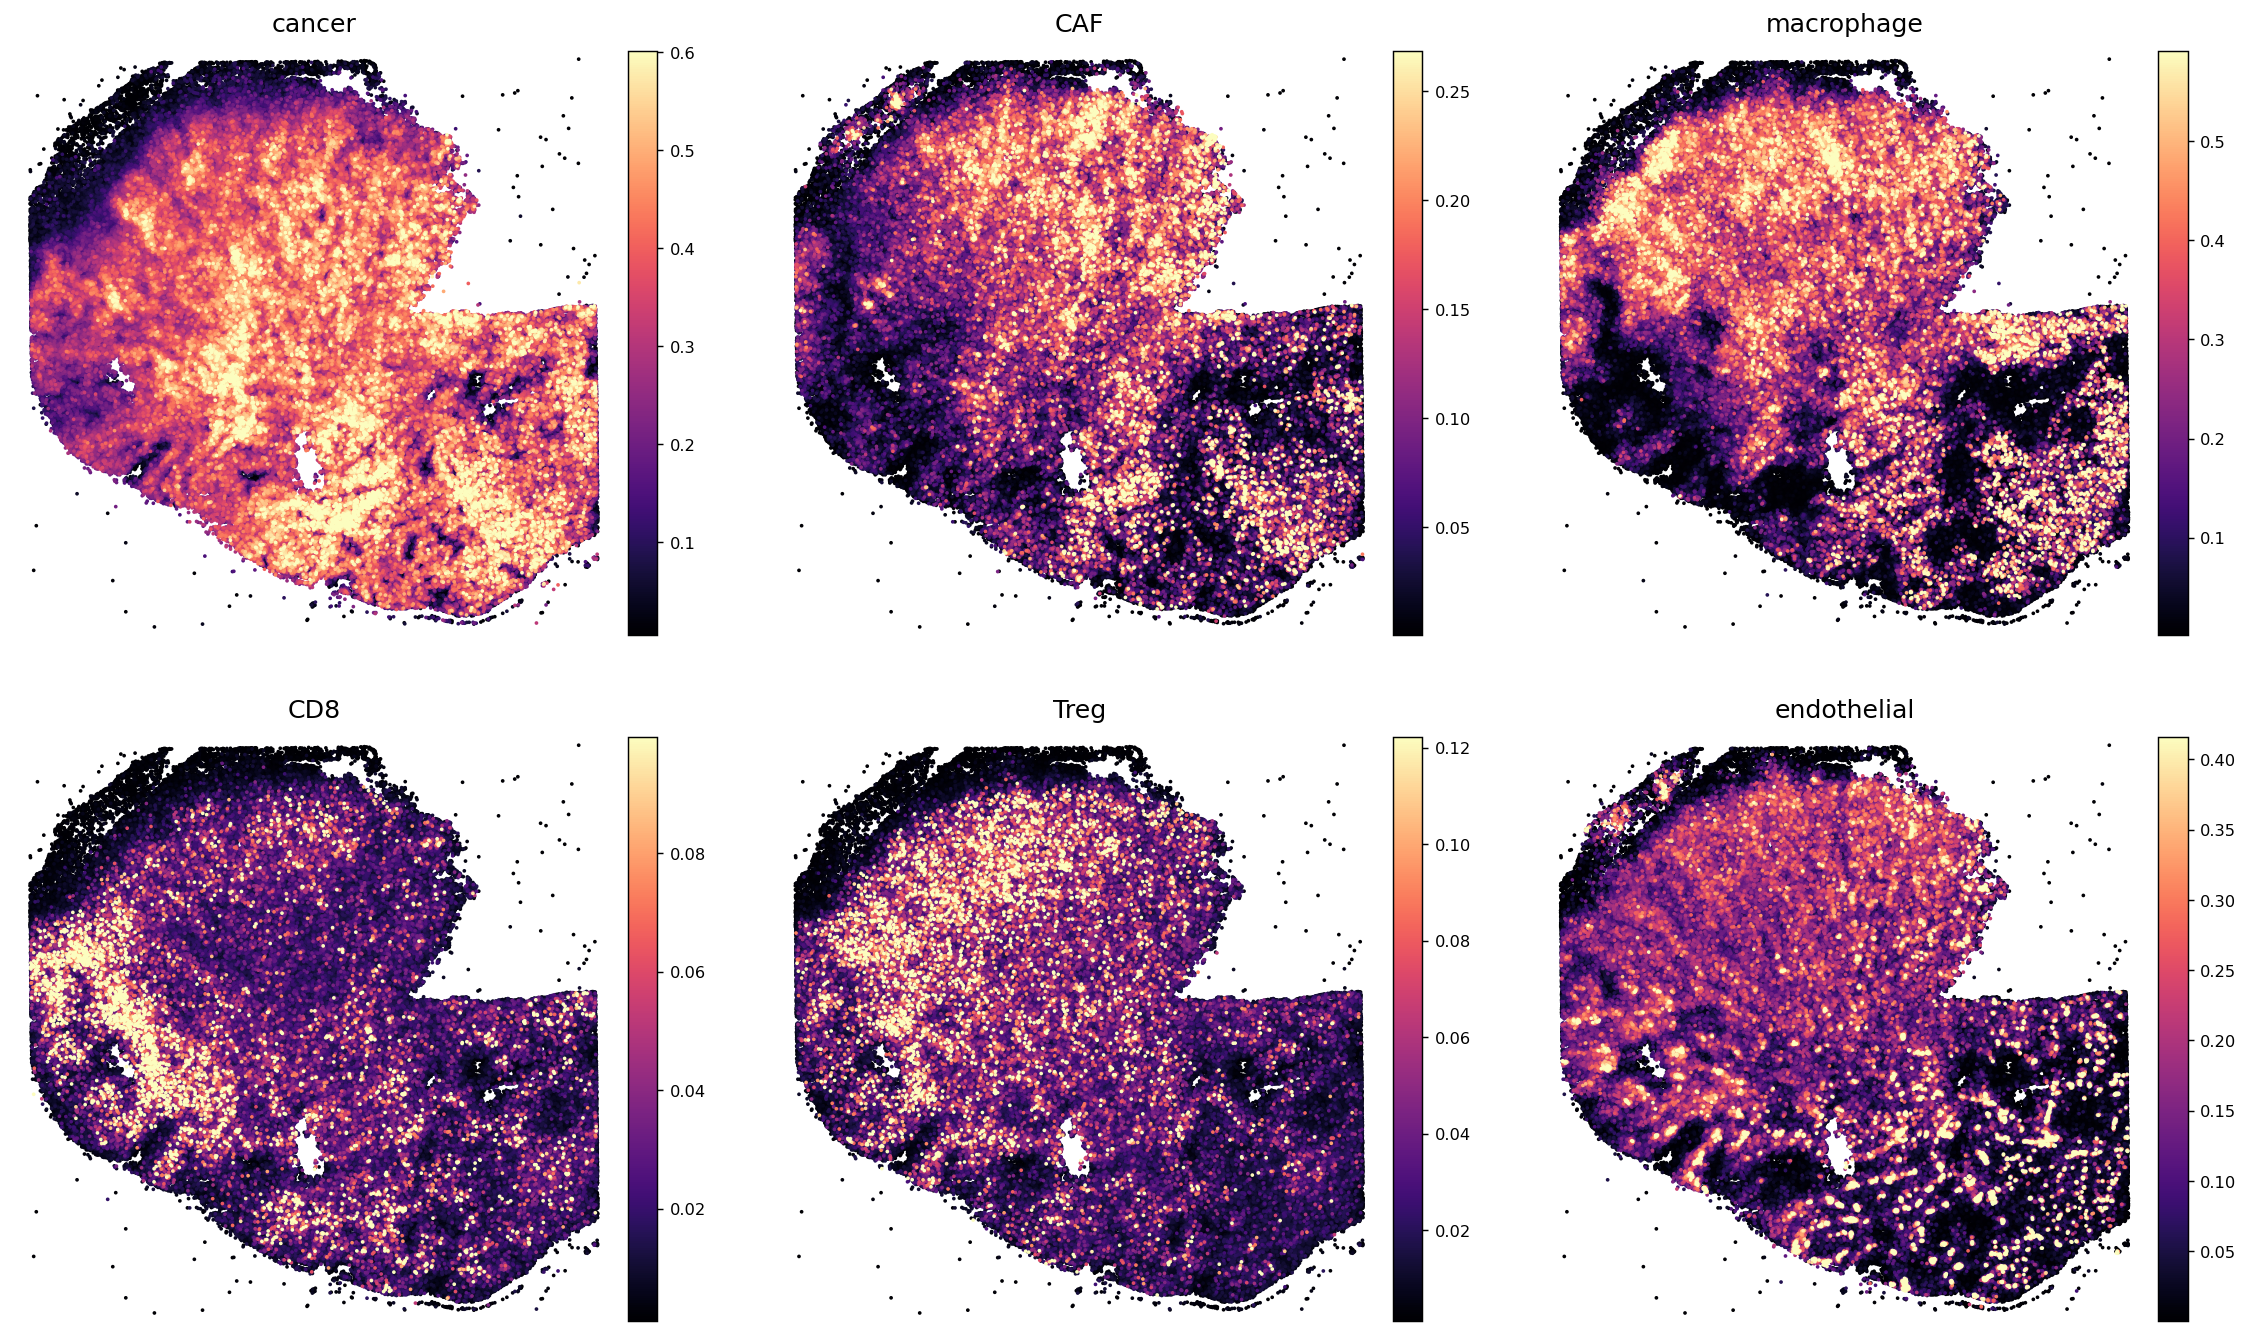

In [5]:
def q05_map(ax, q, ctype):
    cols = q['q05_cols']
    if ctype not in cols:
        ax.set_visible(False); return
    v = q['q05'][:, cols.index(ctype)]
    vmin, vmax = np.percentile(v, [1, 99]); order = np.argsort(v)
    s = ax.scatter(q['XY'][order, 0], q['XY'][order, 1], c=v[order], s=1.1, cmap=SEQ,
                   vmin=vmin, vmax=vmax, rasterized=True)
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    for sp_ in ax.spines.values():
        sp_.set_visible(False)
    ax.margins(0.03); ax.set_title(ctype)
    cb = plt.colorbar(s, ax=ax, fraction=0.045, pad=0.02); cb.ax.tick_params(labelsize=9)

fig, axes = plt.subplots(2, 3, figsize=(17.5, 10.5))
for ax, ct in zip(axes.ravel(), ['cancer', 'CAF', 'macrophage', 'CD8', 'Treg', 'endothelial']):
    q05_map(ax, QC['1RR'], ct)
fig.tight_layout(); fig.subplots_adjust(wspace=0.18, hspace=0.14)


## Marker-gene specificity heatmap

Mean expression of canonical reference markers per cell type, **per-gene normalised**
so each gene's top type = 1. A clean diagonal means the annotation is sensible. Only
the marker-gene columns are read from the h5ad.


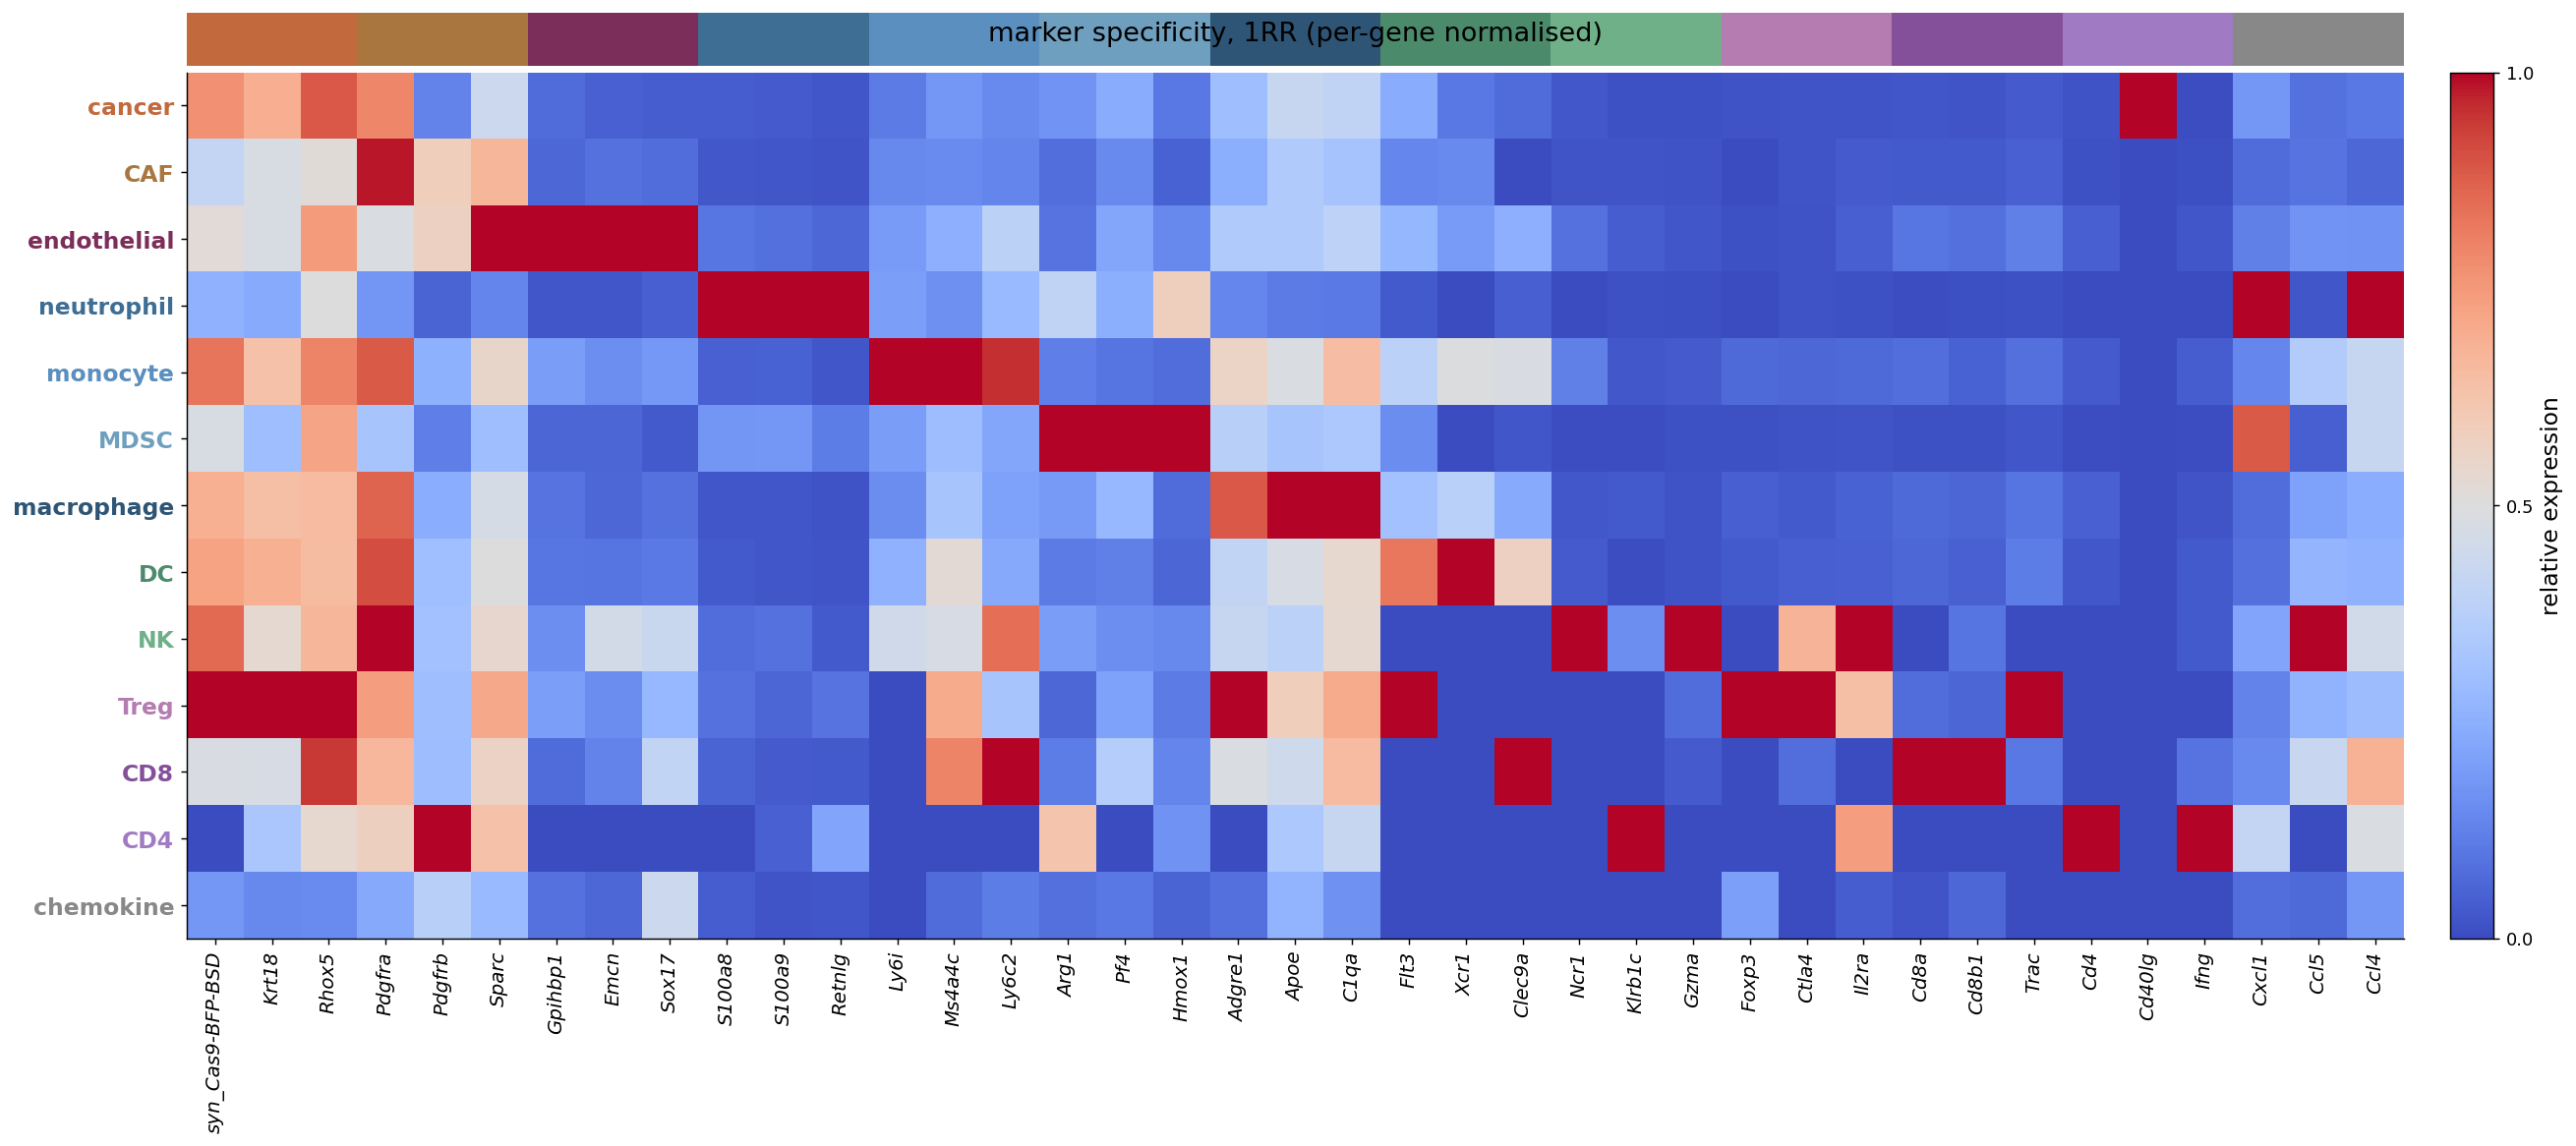

In [6]:
REFERENCE = {
    'cancer': ['syn_Cas9-BFP-BSD', 'Krt18', 'Rhox5'], 'CAF': ['Pdgfra', 'Pdgfrb', 'Sparc'],
    'endothelial': ['Gpihbp1', 'Emcn', 'Sox17'], 'neutrophil': ['S100a8', 'S100a9', 'Retnlg'],
    'monocyte': ['Ly6i', 'Ms4a4c', 'Ly6c2'], 'MDSC': ['Arg1', 'Pf4', 'Hmox1'],
    'macrophage': ['Adgre1', 'Apoe', 'C1qa'], 'DC': ['Flt3', 'Xcr1', 'Clec9a'],
    'NK': ['Ncr1', 'Klrb1c', 'Gzma'], 'Treg': ['Foxp3', 'Ctla4', 'Il2ra'],
    'CD8': ['Cd8a', 'Cd8b1', 'Trac'], 'CD4': ['Cd4', 'Cd40lg', 'Ifng'],
    'chemokine': ['Cxcl1', 'Ccl5', 'Ccl4']}

def marker_heatmap(sample):
    a = ad.read_h5ad(DATA / f'visium_{sample}_cells_final.h5ad', backed='r')
    genes, gtypes = [], []
    for t in CELLTYPE_ORDER:
        for g in REFERENCE[t]:
            if g in a.var_names and g not in genes:
                genes.append(g); gtypes.append(t)
    ct = a.obs['cell_type'].astype(str).values
    X = a[:, [a.var_names.get_loc(g) for g in genes]].X
    X = X.toarray() if sp.issparse(X) else np.asarray(X)
    a.file.close()
    M = np.zeros((len(CELLTYPE_ORDER), len(genes)))
    for i, t in enumerate(CELLTYPE_ORDER):
        m = ct == t
        if m.any():
            M[i] = X[m].mean(0)
    return genes, gtypes, M / np.clip(M.max(0, keepdims=True), 1e-9, None)

genes, gtypes, norm = marker_heatmap('1RR')
fig, ax = plt.subplots(figsize=(0.42 * len(genes) + 4, 0.55 * len(CELLTYPE_ORDER) + 2))
im = ax.imshow(norm, cmap='coolwarm', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(genes))); ax.set_xticklabels(genes, rotation=90, style='italic', fontsize=11)
ax.set_yticks(range(len(CELLTYPE_ORDER))); ax.set_yticklabels(CELLTYPE_ORDER, fontsize=13)
for lb in ax.get_yticklabels():
    lb.set_color(CELLTYPE_PALETTE.get(lb.get_text(), '#222')); lb.set_fontweight('bold')
for k, t in enumerate(gtypes):
    ax.add_patch(Rectangle((k - 0.5, -1.4), 1, 0.8, clip_on=False, color=CELLTYPE_PALETTE.get(t, '#888'), lw=0))
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, ticks=[0, 0.5, 1])
cb.set_label('relative expression', fontsize=13)
ax.set_title('marker specificity, 1RR (per-gene normalised)', fontsize=15, pad=18)
fig.tight_layout()


## Spatial density of the barcode RNA

Total barcode reads per cell, binned in space. Barcode signal concentrates in the
tumour-rich territories — the raw signal the transfer analysis (notebook 07)
quantifies.


1RR: 109,072 cells with barcode reads, total 202,584 UMIs
2N: 78,060 cells with barcode reads, total 155,130 UMIs


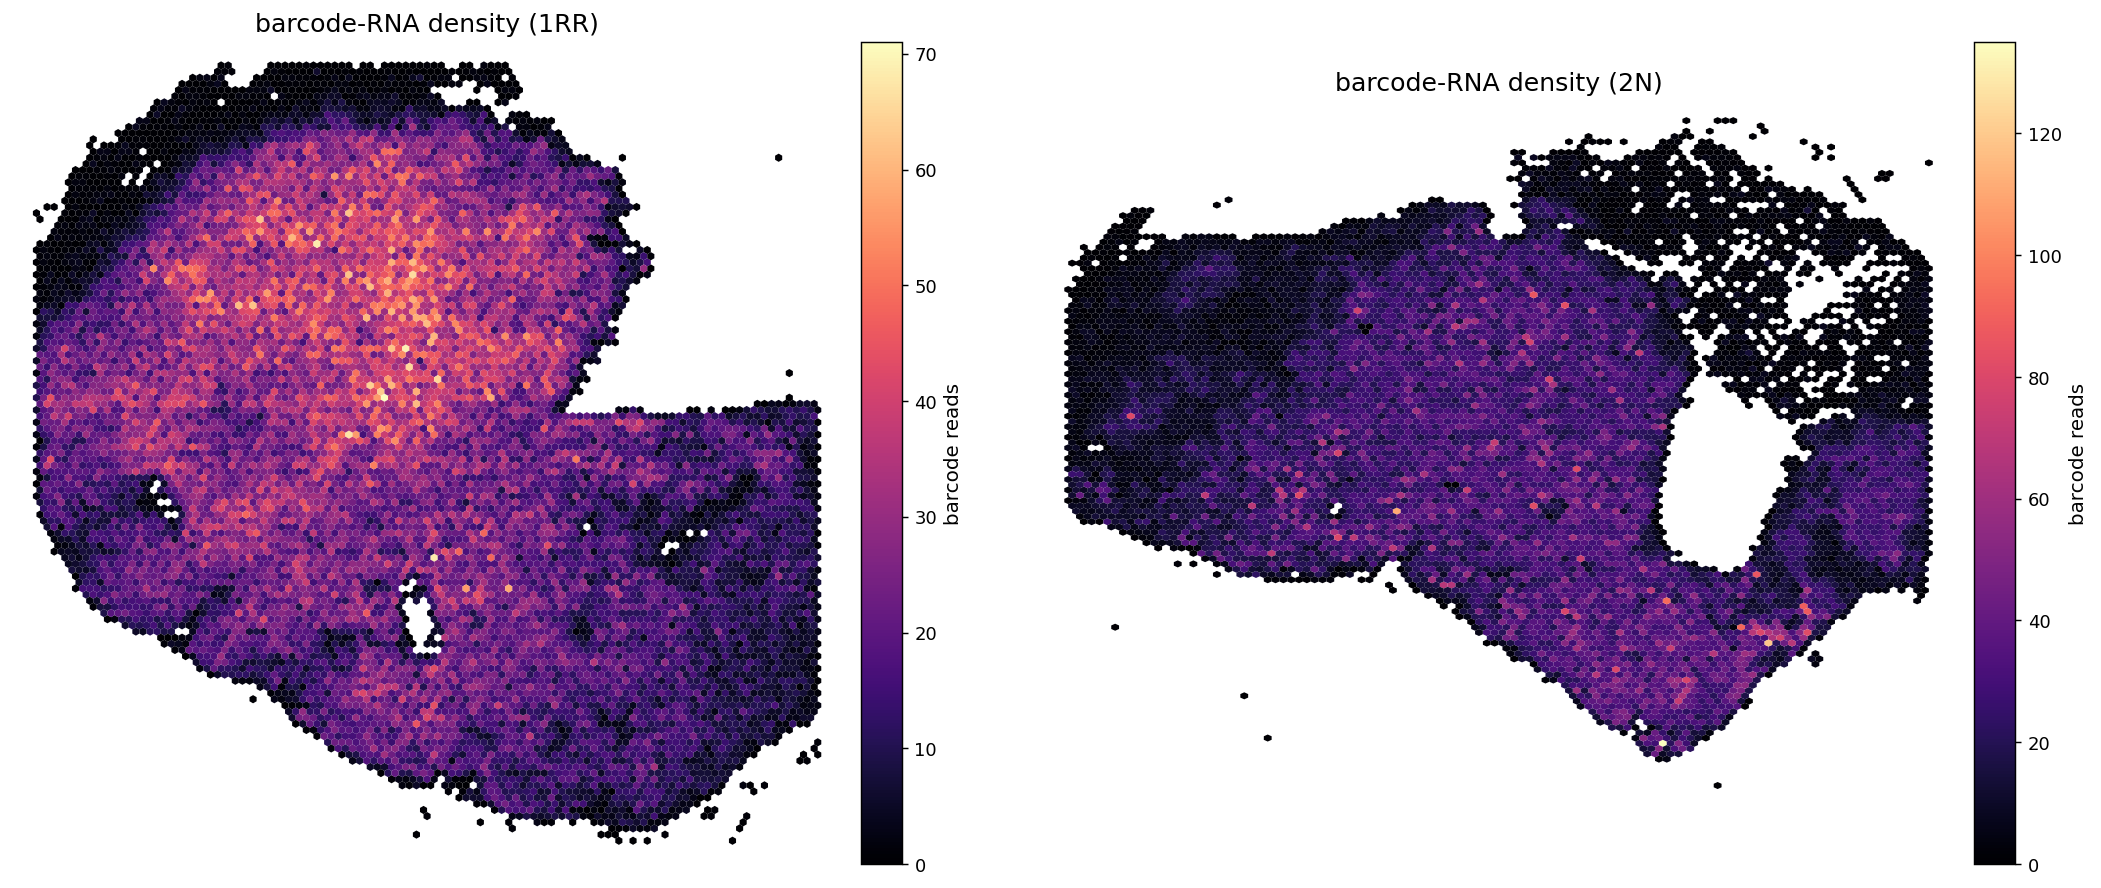

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, s in zip(axes, SAMPLES):
    XY, M, _ = load_barcode(s, QC[s])
    lab = np.asarray(M.sum(1)).ravel().astype(float)
    hb = ax.hexbin(XY[:, 0], XY[:, 1], C=lab, reduce_C_function=np.sum, gridsize=110,
                   cmap=SEQ, mincnt=1, linewidths=0)
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([])
    for sp_ in ax.spines.values():
        sp_.set_visible(False)
    ax.margins(0.03); ax.set_title(f'barcode-RNA density ({s})')
    cb = plt.colorbar(hb, ax=ax, fraction=0.046, pad=0.02); cb.set_label('barcode reads', fontsize=11)
    print(f'{s}: {int((lab>0).sum()):,} cells with barcode reads, total {int(lab.sum()):,} UMIs')
fig.tight_layout(); fig.subplots_adjust(wspace=0.14)


## Sequencing depth vs matched scRNA-seq

Per cell, the Visium HD aggregates are ~1 order of magnitude shallower than the
matched dissociated scRNA-seq — the sparsity budget every spatial analysis lives
with.


1RR: scRNA is 20x deeper (UMI)
2N: scRNA is 19x deeper (UMI)


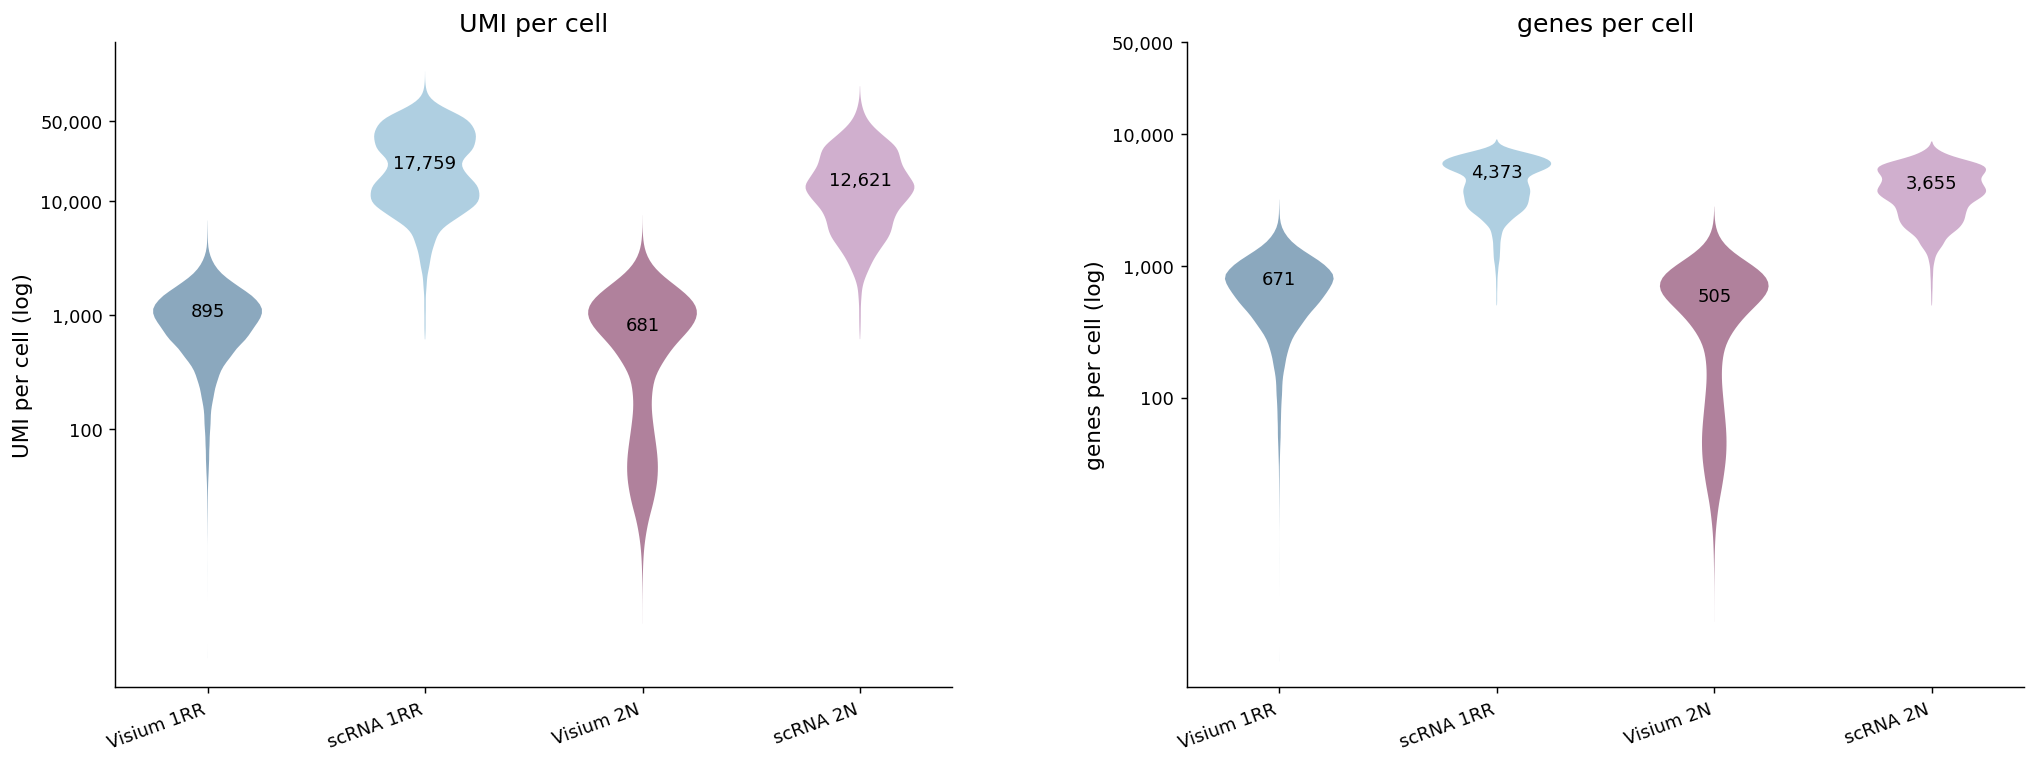

In [8]:
def scrna_obs(sample):
    a = ad.read_h5ad(DATA / f'RNAseq/{sample}.h5ad', backed='r')
    out = (np.asarray(a.obs['total_counts'], float), np.asarray(a.obs['n_genes_by_counts'], float))
    a.file.close(); return out

groups = {}
for s in SAMPLES:
    groups[f'Visium {s}'] = (QC[s]['total_counts'], QC[s]['n_genes'], SAMPLE_COLOR[s])
    tc, ng = scrna_obs(s)
    groups[f'scRNA {s}'] = (tc, ng, SAMPLE_COLOR_SC[s])

def depth_panel(ax, idx, ylabel, title):
    rng = np.random.default_rng(0); labels = list(groups); data, cols = [], []
    for lb in labels:
        v = groups[lb][idx]; v = v[v > 0]
        if len(v) > 30000:
            v = rng.choice(v, 30000, replace=False)
        data.append(np.log10(v)); cols.append(groups[lb][2])
    for b, c in zip(ax.violinplot(data, showextrema=False)['bodies'], cols):
        b.set_facecolor(c); b.set_alpha(0.6); b.set_edgecolor('none')
    for i, lb in enumerate(labels, 1):
        med = float(np.median(groups[lb][idx][groups[lb][idx] > 0]))
        ax.text(i, np.log10(med), f'{med:,.0f}', ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(1, len(labels) + 1)); ax.set_xticklabels(labels, rotation=20, ha='right')
    yt = np.array([100, 1000, 10000, 50000])
    ax.set_yticks(np.log10(yt)); ax.set_yticklabels([f'{v:,}' for v in yt])
    ax.set_ylabel(ylabel); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16.5, 6.4))
depth_panel(axes[0], 0, 'UMI per cell (log)', 'UMI per cell')
depth_panel(axes[1], 1, 'genes per cell (log)', 'genes per cell')
for s in SAMPLES:
    print(f"{s}: scRNA is {np.median(groups[f'scRNA {s}'][0]) / np.median(groups[f'Visium {s}'][0]):.0f}x deeper (UMI)")
fig.tight_layout(); fig.subplots_adjust(wspace=0.28, bottom=0.16, left=0.08, right=0.97)


## Spatial autocorrelation of the barcode signal

If barcode reads reflect real local biology they should be spatially autocorrelated.
For the most-detected barcodes we compute a kNN-weighted **Moran's I** of per-cell
positivity and compare against a permutation null (positivity shuffled across cells).


1RR: observed median Moran I 0.018 vs null -0.000 (150 barcodes)


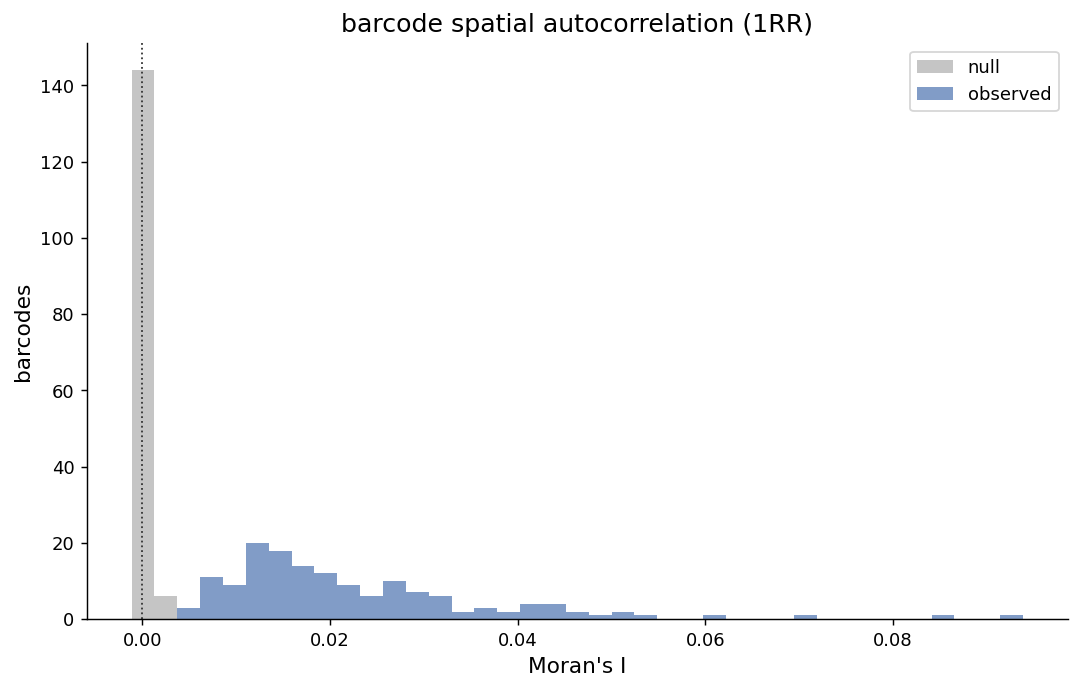

In [9]:
def morans_I(v, idx, w, w_sum):
    v = np.asarray(v, float)
    if v.std() == 0:
        return np.nan
    dv = v - v.mean()
    return float((len(v) / w_sum) * ((w * dv[idx] * dv[:, None]).sum() / (dv ** 2).sum()))

def barcode_moran(sample, n_bc=150, k=30, seed=0):
    XY, M, _ = load_barcode(sample, QC[sample])
    nn = NearestNeighbors(n_neighbors=k + 1, n_jobs=-1).fit(XY)
    d, idx = nn.kneighbors(XY); d, idx = d[:, 1:], idx[:, 1:]
    w = 1.0 / (d + 1.0); w /= w.sum(1, keepdims=True); w_sum = w.sum()
    top = np.argsort(np.asarray((M > 0).sum(0)).ravel())[::-1][:n_bc]
    rng = np.random.default_rng(seed); obs, null = [], []
    for b in top:
        v = np.asarray((M[:, b] > 0).todense()).ravel().astype(float)
        if v.sum() < 5:
            continue
        obs.append(morans_I(v, idx, w, w_sum)); null.append(morans_I(rng.permutation(v), idx, w, w_sum))
    return np.array(obs), np.array(null)

obs, null = barcode_moran('1RR')
fig, ax = plt.subplots(figsize=(8.5, 5.5))
bins = np.linspace(min(null.min(), obs.min()), max(obs.max(), null.max()), 40)
ax.hist(null, bins=bins, color='#bbbbbb', alpha=0.85, label='null')
ax.hist(obs, bins=bins, color=VIS_C, alpha=0.7, label='observed')
ax.axvline(0, color='#333', ls=':', lw=1)
ax.set_xlabel("Moran's I"); ax.set_ylabel('barcodes'); ax.set_title('barcode spatial autocorrelation (1RR)')
ax.legend()
fig.tight_layout()
print(f'1RR: observed median Moran I {np.median(obs):.3f} vs null {np.median(null):.3f} ({len(obs)} barcodes)')


## Barcode coverage per sgRNA

Each sgRNA is delivered on many distinct lentiviral barcodes (clones). Here, per
sgRNA, the number of distinct barcodes detected in the Visium data — the clonal
coverage available for the transfer analyses.


1RR: 133 sgRNAs, median 53 barcodes each, max 405
2N: 130 sgRNAs, median 18 barcodes each, max 139


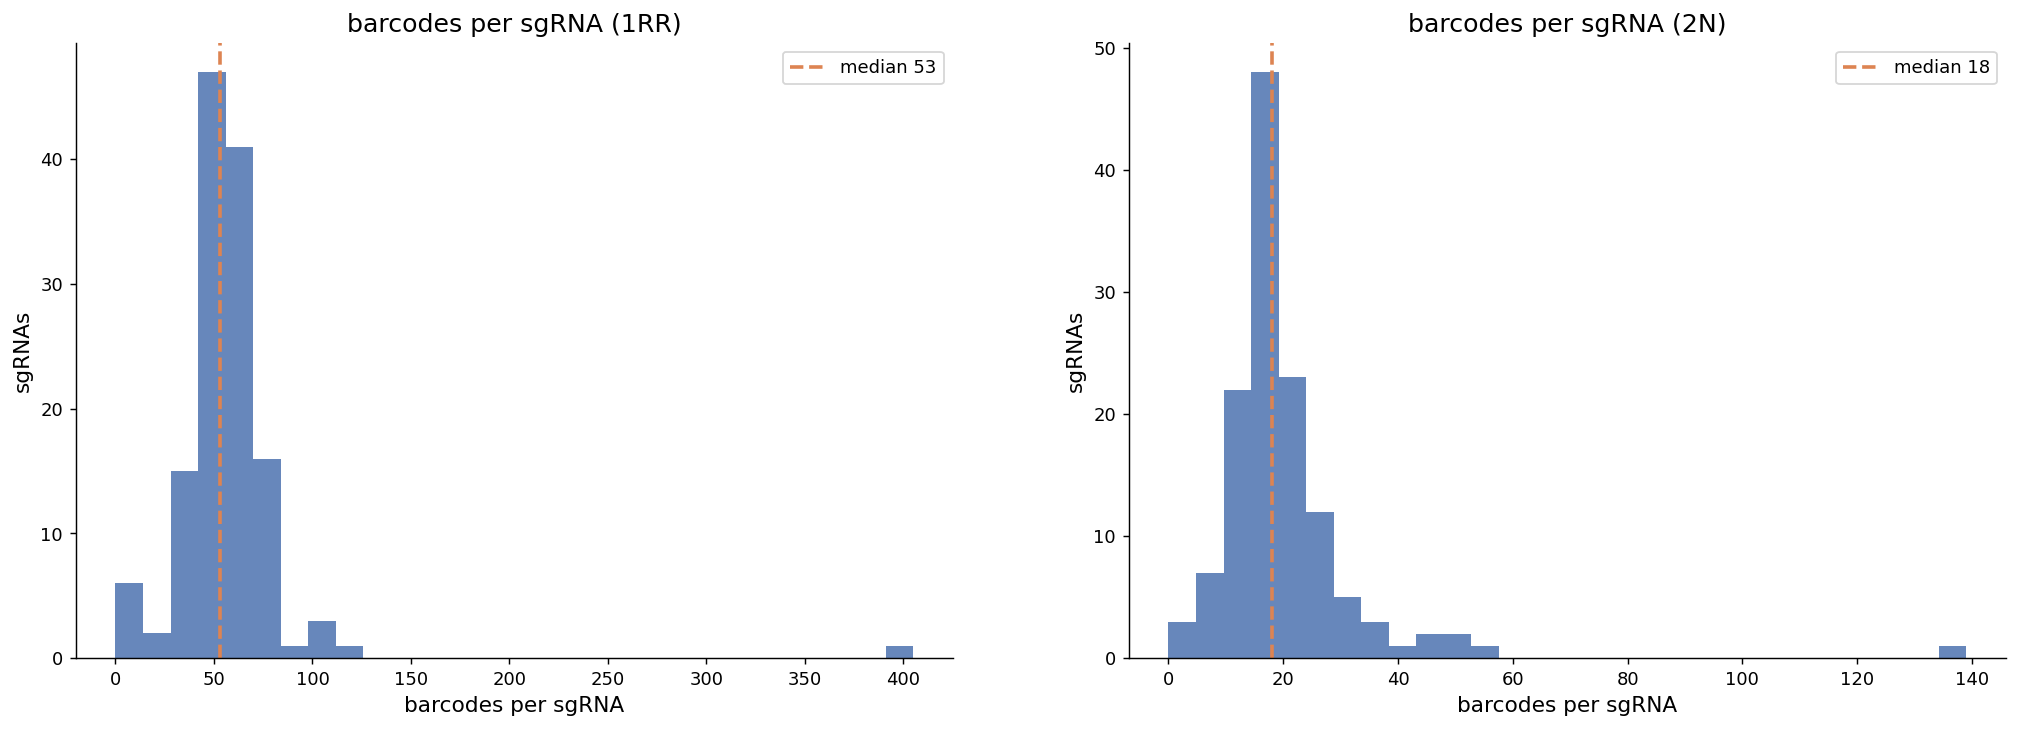

In [10]:
def sgRNA_coverage(sample):
    z = np.load(DATA / f'cell_barcode_{sample}.npz', allow_pickle=True)
    M = sp.csr_matrix((z['data'], z['indices'], z['indptr']), shape=tuple(z['shape'])).tocsc()
    barcodes = z['barcodes'].astype(str)
    detected = np.asarray((M > 0).sum(0)).ravel() >= 3
    sg = np.array([b.split('_', 1)[0] for b in barcodes])
    return pd.Series(sg[detected]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.8))
for ax, s in zip(axes, SAMPLES):
    per = sgRNA_coverage(s)
    ax.hist(per.values, bins=np.linspace(0, per.max(), 30), color=VIS_C, alpha=0.85)
    ax.axvline(per.median(), color=SC_C, ls='--', lw=2, label=f'median {per.median():.0f}')
    ax.set_xlabel('barcodes per sgRNA'); ax.set_ylabel('sgRNAs'); ax.set_title(f'barcodes per sgRNA ({s})')
    ax.legend()
    print(f'{s}: {len(per)} sgRNAs, median {per.median():.0f} barcodes each, max {per.max()}')
fig.tight_layout(); fig.subplots_adjust(wspace=0.2, left=0.07, right=0.97)


---
The sections are annotated into 13 spatially coherent cell-type territories, are
~10× shallower per cell than the matched scRNA-seq, and carry a spatially
autocorrelated barcode signal with several clones per sgRNA — the basis for the
barcode-transfer analysis in notebook 07.
